<a href="https://colab.research.google.com/github/gaurizendekar/Data_Science_labs/blob/main/Exp5_Conv_Nets_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Experiment 5: Advanced Convolutional Neural Networks

Aim:To implement an advanced Convolutional Neural Network (CNN) using TensorFlow and Keras with Dropout layers for improved image classification performance.

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 331s 2us/step


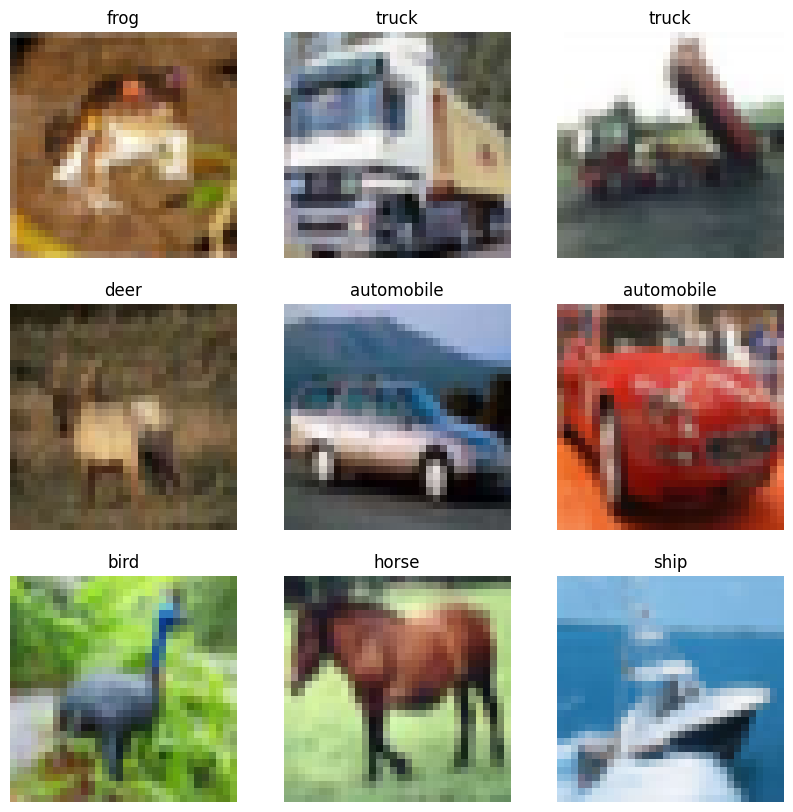

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 10, 10, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       819,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 890,410 (3.40 MB)

 Trainable params: 890,410 (3.40 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 198s 248ms/step - accuracy: 0.4187 - loss: 1.5877 - val_accuracy: 0.5487 - val_loss: 1.2919
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 198s 244ms/step - accuracy: 0.5708 - loss: 1.2074 - val_accuracy: 0.6284 - val_loss: 1.0518
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 203s 245ms/step - accuracy: 0.6297 - loss: 1.0505 - val_accuracy: 0.6731 - val_loss: 0.9185
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 196s 251ms/step - accuracy: 0.6632 - loss: 0.9517 - val_accuracy: 0.6919 - val_loss: 0.8760
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 191s 245ms/step - accuracy: 0.6891 - loss: 0.8857 - val_accuracy: 0.7155 - val_loss: 0.8106
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 201s 244ms/step - accuracy: 0.7127 - loss: 0.8233 - val_accuracy: 0.7332 - val_loss: 0.7785
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 188s 240ms/step - accuracy: 0.7252 - loss: 0.7781 - val_accuracy: 0.7492 - val_loss: 0.7283
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 188s 240ms/step - accuracy: 0.7420 -

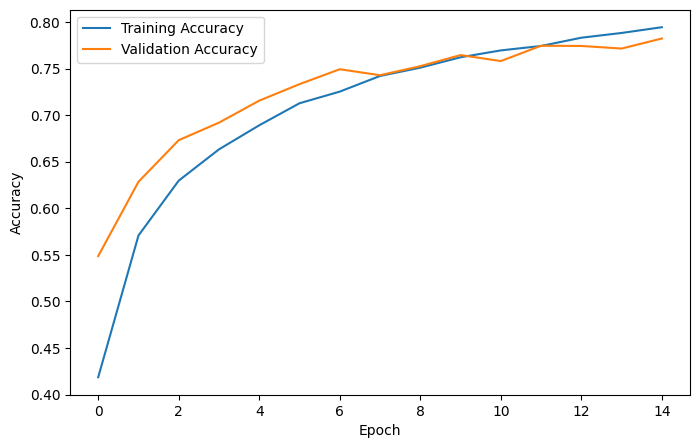

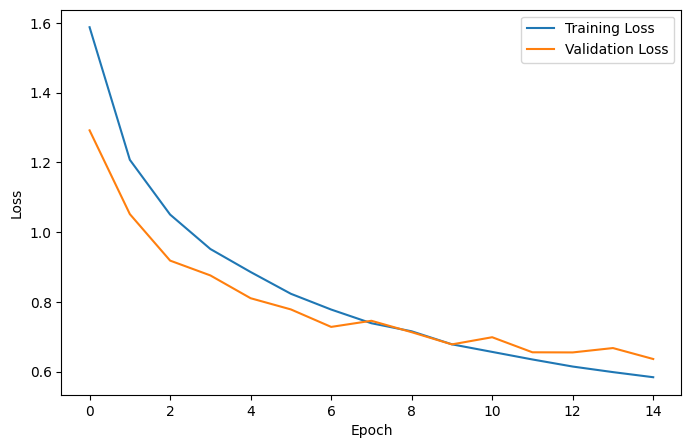

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models, callbacks
import matplotlib.pyplot as plt
import numpy as np

# 1. Load CIFAR-10 Dataset
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()

# 2. Normalize Dataset
X_train = X_train / 255.0
X_test = X_test / 255.0

# Class Names
class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# 3. Display Sample Images
plt.figure(figsize=(10, 10))
for i in range(9):
    plt.subplot(3, 3, i+1)
    plt.imshow(X_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis('off')
plt.tight_layout()
plt.show()

# 4. Build an Enhanced CNN Model
model = models.Sequential()

# Explicit Input Layer (Resolves Keras deprecation warnings)
model.add(layers.Input(shape=(32, 32, 3)))

# First Convolution Block
model.add(layers.Conv2D(32, (3,3), padding='same', activation='relu'))
model.add(layers.BatchNormalization()) # Added Batch Normalization
model.add(layers.Conv2D(32, (3,3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Dropout(0.25))

# Second Convolution Block
model.add(layers.Conv2D(64, (3,3), padding='same', activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Dropout(0.25))

# Third Convolution Block (Added to make the model extract deeper features)
model.add(layers.Conv2D(128, (3,3), padding='same', activation='relu'))
model.add(layers.BatchNormalization())
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Dropout(0.25))

# Flatten Layer
model.add(layers.Flatten())

# Fully Connected Layers
model.add(layers.Dense(256, activation='relu')) # Adjusted to 256 for efficiency
model.add(layers.BatchNormalization())
model.add(layers.Dropout(0.5))
model.add(layers.Dense(10, activation='softmax'))

# Model Summary
model.summary()

# 5. Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# 6. Callbacks (Added Early Stopping)
early_stopping = callbacks.EarlyStopping(
    monitor='val_loss', 
    patience=3, # Stops if validation loss doesn't improve for 3 epochs
    restore_best_weights=True
)

# 7. Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=15,
    batch_size=64,
    validation_data=(X_test, y_test),
    callbacks=[early_stopping] # Incorporating the callback
)

# 8. Evaluate Model
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nTest Accuracy: {test_accuracy:.4f}")
print(f"Test Loss: {test_loss:.4f}")

# 9. Plot Accuracy and Loss Graphs (Side-by-Side View)
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Plot Accuracy
ax[0].plot(history.history['accuracy'], label='Training Accuracy', color='blue')
ax[0].plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
ax[0].set_xlabel('Epoch')
ax[0].set_ylabel('Accuracy')
ax[0].set_title('Model Accuracy')
ax[0].legend()
ax[0].grid(True)

# Plot Loss
ax[1].plot(history.history['loss'], label='Training Loss', color='blue')
ax[1].plot(history.history['val_loss'], label='Validation Loss', color='orange')
ax[1].set_xlabel('Epoch')
ax[1].set_ylabel('Loss')
ax[1].set_title('Model Loss')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

Conclusion: Successfully implemented an advanced CNN model using multiple convolution layers and dropout regularization for image classification on the CIFAR-10 dataset.